### Exploring Z2 changes in 202410 version

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import arrow
import netCDF4 as nc
import cmocean.cm as cm
import pandas as pd


In [2]:
bathy = nc.Dataset('/home/sallen/MEOPAR/grid/bathymetry_202108.nc','r')
mesh = xr.open_dataset('/ocean/atall/MOAD/grid/mesh_mask202108.nc')
mbathy = mesh.mbathy
depth = mesh.variables['gdept_0'][:]
thalweg_HC = '/ocean/atall/MOAD/analysis-abdoul/notebooks/thalweg_work/thalweg_files/JoseTallthalwegPS.txt' 
thalweg_SoG = '/home/sallen/MEOPAR/Tools/bathymetry/thalweg_working.txt'
thalweg_ptsSoG = np.loadtxt(thalweg_SoG, delimiter=' ', dtype=int)
thalweg_ptsHC = np.loadtxt(thalweg_HC, delimiter=' ', dtype=int)
thalwegs =list([thalweg_ptsSoG,thalweg_ptsHC[::-1]])
depmin = list([450,170])

In [4]:
# Time settings
syear, smonth, sday = (2018, 1, 1)
eyear, emonth, eday = (2018, 7, 31)
startdate = arrow.get(syear, smonth, sday)
enddate = arrow.get(eyear, emonth, eday)

# Directories
dir = '/ocean/atall/MOAD/Model/202410b/oxygen/'
dir21 = '/results2/SalishSea/nowcast-green.202111/'
dirNut = '/ocean/atall/MOAD/Model/202410b/wastewatero2/'
dirNutnoOM = '/ocean/atall/MOAD/Model/202410b/wastewatero2_zeroNutnoOM/'
dirnoNut = '/ocean/atall/MOAD/Model/202410b/wastewatero2_zeroNut/'

# Containers
pon, pon_21, don, don_21, nh4, nh4_21, do, do_21 = [], [], [], [], [], [], [], []
pon_Nut, pon_NutnoOM, pon_noNut, don_Nut, don_NutnoOM, don_noNut, nh4_Nut, nh4_NutnoOM, nh4_noNut, do_Nut, do_NutnoOM, do_noNut = [], [], [], [], [], [], [], [], [], [], [], []
Z2, Z2_21 = [], []
Z1grz_list, Z1mrt_list = [], []
grz_list, res_list, exc_list, mrt_list = [], [], [], []
grz_list21, res_list21 = [], [],
grz_list2D, exc_list2D, mrt_list2D = [], [], []
# Loop over days
for day in arrow.Arrow.range('day', startdate, enddate):
    year = day.year
    yr2 = day.strftime("%y")
    month = day.month
    Month = day.strftime("%b").lower()
    dayn = day.day

    # Filenames

    fn_chem = f'{dir}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_chem_T.nc'
    fn_chem21 = f'{dir21}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_chem_T.nc'
    fn_chemNut = f'{dirNut}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_chem_T.nc'
    #fn_chemNutnoOM = f'{dirNutnoOM}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_chem_T.nc'
    fn_chemnoNut = f'{dirnoNut}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_chem_T.nc'

    #fn_graz = f'{dir}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_graz_T.nc'
    #fn_graz21 = f'{dir21}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_graz_T.nc'
    
    fn_biol = f'{dir}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_biol_T.nc'
    fn_biol21 = f'{dir21}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_biol_T.nc'
    fn_biolNut = f'{dirNut}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_biol_T.nc'
    #fn_biolNutnoOM = f'{dirNutnoOM}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_biol_T.nc'
    fn_biolnoNut = f'{dirnoNut}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_biol_T.nc'

    # Open datasets
    ds_chem = xr.open_dataset(fn_chem)
    ds_chem21 = xr.open_dataset(fn_chem21)
    ds_chemNut = xr.open_dataset(fn_chemNut)
    #ds_chemNutnoOM = xr.open_dataset(fn_chemNutnoOM)
    ds_chemnoNut = xr.open_dataset(fn_chemnoNut)
    ds_biol = xr.open_dataset(fn_biol)
    ds_biol21 = xr.open_dataset(fn_biol21)
    ds_biolNut = xr.open_dataset(fn_biolNut)
    #ds_biolNutnoOM = xr.open_dataset(fn_biolNutnoOM)
    ds_biolnoNut = xr.open_dataset(fn_biolnoNut)
    #ds_graz = xr.open_dataset(fn_graz)
    #ds_graz21 = xr.open_dataset(fn_graz21)
    
    do_sum = ds_chem.dissolved_oxygen.sum()
    do.append(do_sum)
    do_sum21 = ds_chem21.dissolved_oxygen.sum()
    do_21.append(do_sum21)
    do_sumNut = ds_chemNut.dissolved_oxygen.sum()
    do_Nut.append(do_sumNut)
    #do_sumNutnoOM = ds_chemNutnoOM.dissolved_oxygen.sum()
    #do_NutnoOM.append(do_sumNutnoOM)
    do_sumnoNut = ds_chemnoNut.dissolved_oxygen.sum()
    do_noNut.append(do_sumnoNut)

    pon_sum = ds_biol.particulate_organic_nitrogen.sum()
    pon.append(pon_sum)
    pon_sum21 = ds_biol21.particulate_organic_nitrogen.sum()
    pon_21.append(pon_sum21)
    pon_sumNut = ds_biolNut.particulate_organic_nitrogen.sum()
    pon_Nut.append(pon_sumNut)
    #pon_sumNutnoOM = ds_biolNutnoOM.particulate_organic_nitrogen.sum()
    #pon_NutnoOM.append(pon_sumNutnoOM)
    pon_sumnoNut = ds_biolnoNut.particulate_organic_nitrogen.sum()
    pon_noNut.append(pon_sumnoNut)

    don_sum = ds_biol.nitrate.sum()
    don.append(don_sum)
    don_sum21 = ds_biol21.nitrate.sum()
    don_21.append(don_sum21)
    don_sumNut = ds_biolNut.nitrate.sum()
    don_Nut.append(don_sumNut)
    #don_sumNutnoOM = ds_biolNutnoOM.nitrate.sum()
    #don_NutnoOM.append(don_sumNutnoOM)
    don_sumnoNut = ds_biolnoNut.nitrate.sum()
    don_noNut.append(don_sumnoNut)

    nh4_sum = ds_biol.ammonium.sum()
    nh4.append(nh4_sum)
    nh4_sum21 = ds_biol21.ammonium.sum()
    nh4_21.append(nh4_sum21)
    nh4_sumNut = ds_biolNut.ammonium.sum()
    nh4_Nut.append(nh4_sumNut)
    #nh4_sumNutnoOM = ds_biolNutnoOM.ammonium.sum()
    #nh4_NutnoOM.append(nh4_sumNutnoOM)
    nh4_sumnoNut = ds_biolnoNut.ammonium.sum()
    nh4_noNut.append(nh4_sumnoNut)



    #Z2_sum = ds_biol.mesozooplankton.sum()
    #Z2.append(Z2_sum)
    #Z2_sum21 = ds_biol21.mesozooplankton.sum()
    #Z2_21.append(Z2_sum21)
    #Z1grz = ds_graz.GRMICZMICZ.sum() + ds_graz.GRMICZPON.sum() + ds_graz.GRMICZPHY.sum() + ds_graz.GRMICZDIAT.sum()
    #Z1mrt = ds_graz.MORTMICZ.sum()
    #Z1grz_list.append(Z1grz)
    #Z1mrt_list.append(Z1mrt)

    #Z2grz21 = ds_graz21.GRMESZMICZ.sum() + ds_graz21.GRMESZPON.sum() + ds_graz21.GRMESZPHY.sum() + ds_graz21.GRMESZDIAT.sum()
    #grz_list21.append(Z2grz21)

    #Z2grz2D = ds_graz.GRMESZMICZ.sum(axis=0).sum(axis=0) + ds_graz.GRMESZPON.sum(axis=0).sum(axis=0) + ds_graz.GRMESZPHY.sum(axis=0).sum(axis=0) + ds_graz.GRMESZDIAT.sum(axis=0).sum(axis=0)
    #Z2mrt2D = ds_graz.Z2_NATMORT.sum(axis=0).sum(axis=0)
    #Z2exc2D = ds_graz.Z2_EXCR.sum(axis=0).sum(axis=0)
    #Z2grz = ds_graz.GRMESZMICZ.sum() + ds_graz.GRMESZPON.sum() + ds_graz.GRMESZPHY.sum() + ds_graz.GRMESZDIAT.sum()
    #Z2mrt = ds_graz.Z2_NATMORT.sum()
    #Z2exc = ds_graz.Z2_EXCR.sum()
    #Z2res = Z2mrt + Z2exc
    
    #grz_list.append(Z2grz)
    #exc_list.append(Z2exc)
    #mrt_list.append(Z2mrt)
    #res_list.append(Z2res)
    #grz_list2D.append(Z2grz2D)
    #exc_list2D.append(Z2exc2D)
    #mrt_list2D.append(Z2mrt2D)


# Convert to xarray.DataArray along time
time_index = pd.date_range(start=f"{syear}-{smonth:02}-{sday:02}", end=f"{eyear}-{emonth:02}-{eday:02}", freq="D")

#grz_da = xr.concat(grz_list2D, dim='time_counter')
#mrt_da = xr.concat(mrt_list2D, dim='time_counter')
#exc_da = xr.concat(exc_list2D, dim='time_counter')

#grz_da['time_counter'] = time_index[:len(grz_list2D)]
#mrt_da['time_counter'] = time_index[:len(mrt_list2D)]
#exc_da['time_counter'] = time_index[:len(exc_list2D)]

Text(0, 0.5, 'DO (mmol m$^{-3}$)')

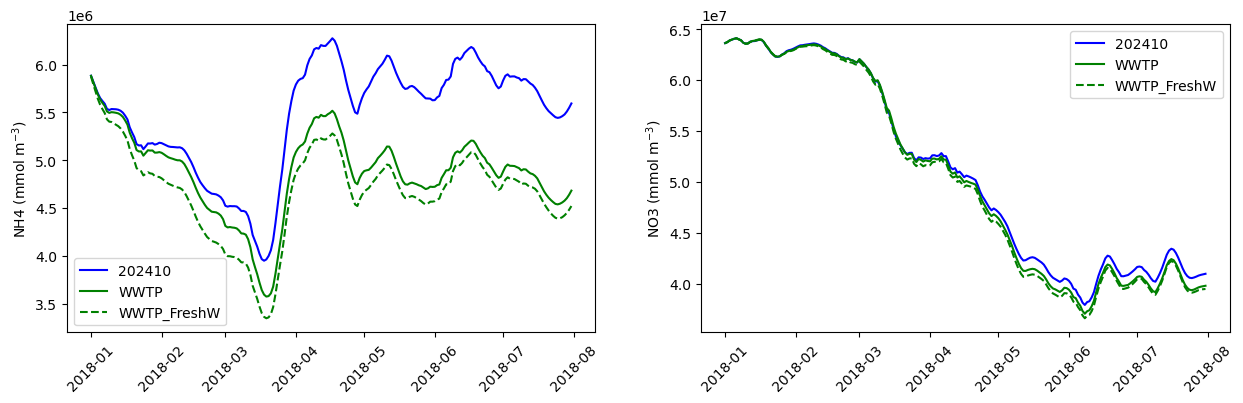

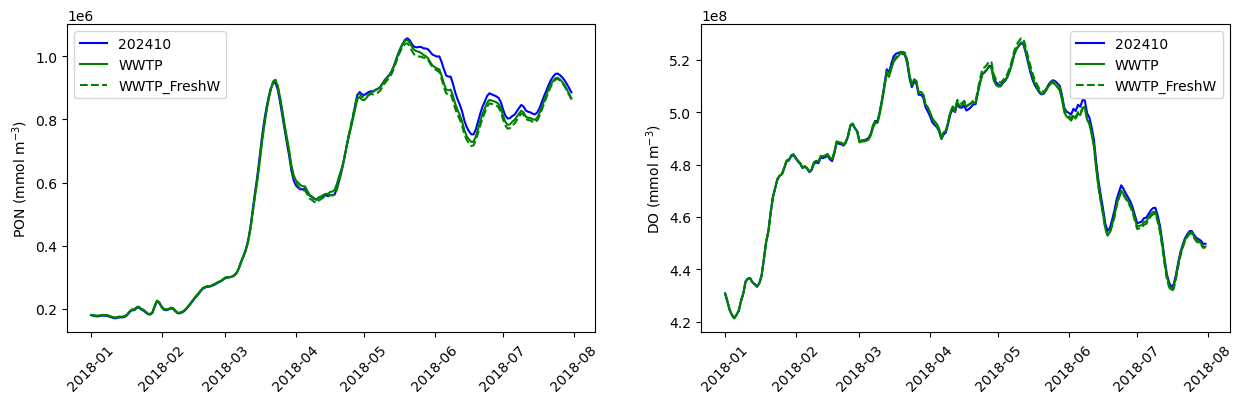

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
#ax[0].plot(time_index,nh4_21,'r',label='202111')
ax[0].plot(time_index,nh4,'b',label='202410')
ax[0].plot(time_index,nh4_Nut,'g',label='WWTP')
#ax[0].plot(time_index,nh4_NutnoOM,'g',linestyle='dotted',label='WWTP_noPONDON')
ax[0].plot(time_index,nh4_noNut,'g',linestyle='dashed',label='WWTP_FreshW')
ax[0].legend()
ax[0].tick_params(axis='x', labelrotation=45)
ax[0].set_ylabel('NH4 (mmol m$^{-3}$)')
#ax[1].plot(time_index,don_21,'r',label='202111')
ax[1].plot(time_index,don,'b',label='202410')
ax[1].plot(time_index,don_Nut,'g',label='WWTP')
#ax[1].plot(time_index,don_NutnoOM,'g',linestyle='dotted',label='WWTP_noPONDON')
ax[1].plot(time_index,don_noNut,'g',linestyle='dashed',label='WWTP_FreshW')
ax[1].legend()
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].set_ylabel('NO3 (mmol m$^{-3}$)')


fig, ax = plt.subplots(1, 2, figsize=(15, 4))
#ax[0].plot(time_index,pon_21,'r',label='202111')
ax[0].plot(time_index,pon,'b',label='202410')
ax[0].plot(time_index,pon_Nut,'g',label='WWTP')
#ax[0].plot(time_index,pon_NutnoOM,'g',linestyle='dotted',label='WWTP_noPONDON')
ax[0].plot(time_index,pon_noNut,'g',linestyle='dashed',label='WWTP_FreshW')
ax[0].legend()
ax[0].tick_params(axis='x', labelrotation=45)
ax[0].set_ylabel('PON (mmol m$^{-3}$)')
#ax[1].plot(time_index,do_21,'r',label='202111')
ax[1].plot(time_index,do,'b',label='202410')
ax[1].plot(time_index,do_Nut,'g',label='WWTP')
#ax[1].plot(time_index,do_NutnoOM,'g',linestyle='dotted',label='WWTP_noPONDON')
ax[1].plot(time_index,do_noNut,'g',linestyle='dashed',label='WWTP_FreshW')
ax[1].legend()
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].set_ylabel('DO (mmol m$^{-3}$)')


Text(0, 0.5, 'DO (mmol m$^{-3}$)')

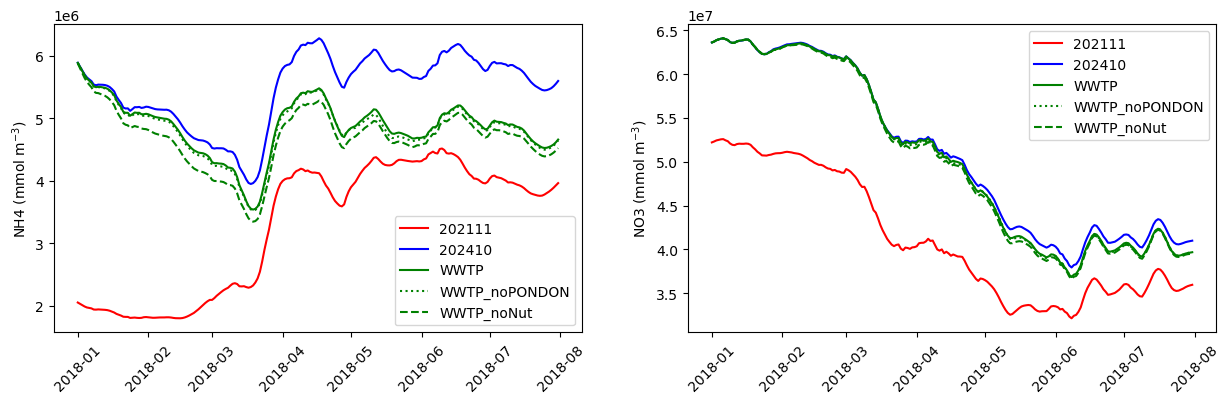

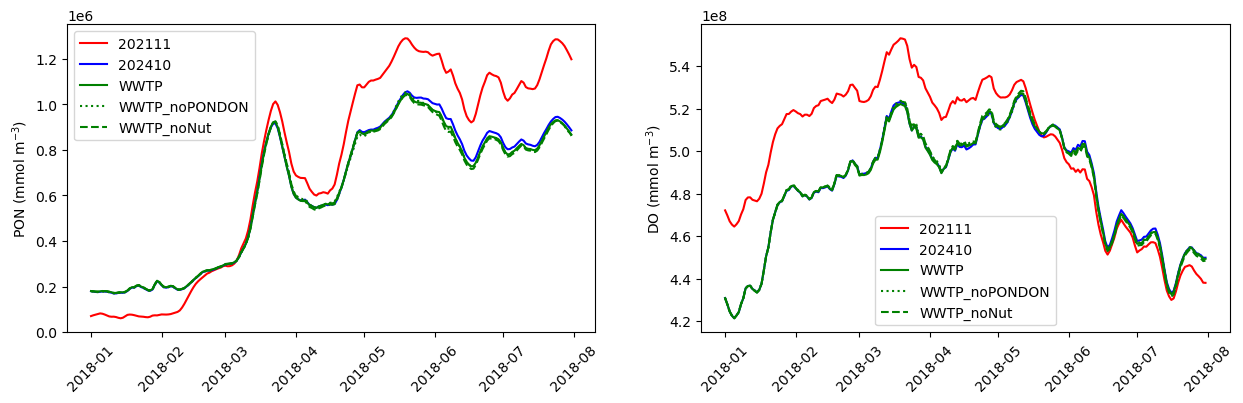

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(time_index,nh4_21,'r',label='202111')
ax[0].plot(time_index,nh4,'b',label='202410')
ax[0].plot(time_index,nh4_Nut,'g',label='WWTP')
ax[0].plot(time_index,nh4_NutnoOM,'g',linestyle='dotted',label='WWTP_noPONDON')
ax[0].plot(time_index,nh4_noNut,'g',linestyle='dashed',label='WWTP_noNut')
ax[0].legend()
ax[0].tick_params(axis='x', labelrotation=45)
ax[0].set_ylabel('NH4 (mmol m$^{-3}$)')
ax[1].plot(time_index,don_21,'r',label='202111')
ax[1].plot(time_index,don,'b',label='202410')
ax[1].plot(time_index,don_Nut,'g',label='WWTP')
ax[1].plot(time_index,don_NutnoOM,'g',linestyle='dotted',label='WWTP_noPONDON')
ax[1].plot(time_index,don_noNut,'g',linestyle='dashed',label='WWTP_noNut')
ax[1].legend()
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].set_ylabel('NO3 (mmol m$^{-3}$)')


fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(time_index,pon_21,'r',label='202111')
ax[0].plot(time_index,pon,'b',label='202410')
ax[0].plot(time_index,pon_Nut,'g',label='WWTP')
ax[0].plot(time_index,pon_NutnoOM,'g',linestyle='dotted',label='WWTP_noPONDON')
ax[0].plot(time_index,pon_noNut,'g',linestyle='dashed',label='WWTP_noNut')
ax[0].legend()
ax[0].tick_params(axis='x', labelrotation=45)
ax[0].set_ylabel('PON (mmol m$^{-3}$)')
ax[1].plot(time_index,do_21,'r',label='202111')
ax[1].plot(time_index,do,'b',label='202410')
ax[1].plot(time_index,do_Nut,'g',label='WWTP')
ax[1].plot(time_index,do_NutnoOM,'g',linestyle='dotted',label='WWTP_noPONDON')
ax[1].plot(time_index,do_noNut,'g',linestyle='dashed',label='WWTP_noNut')
ax[1].legend()
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].set_ylabel('DO (mmol m$^{-3}$)')


In [8]:
np.sum(res_list)/np.sum(grz_list)

0.31850916

Text(0, 0.5, 'DO (mmol O$_2$ m$^{-3}$)')

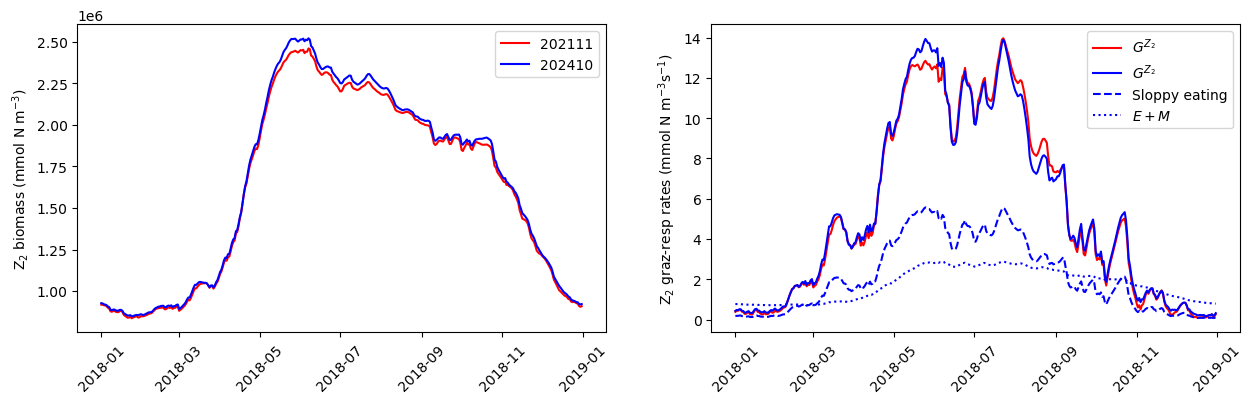

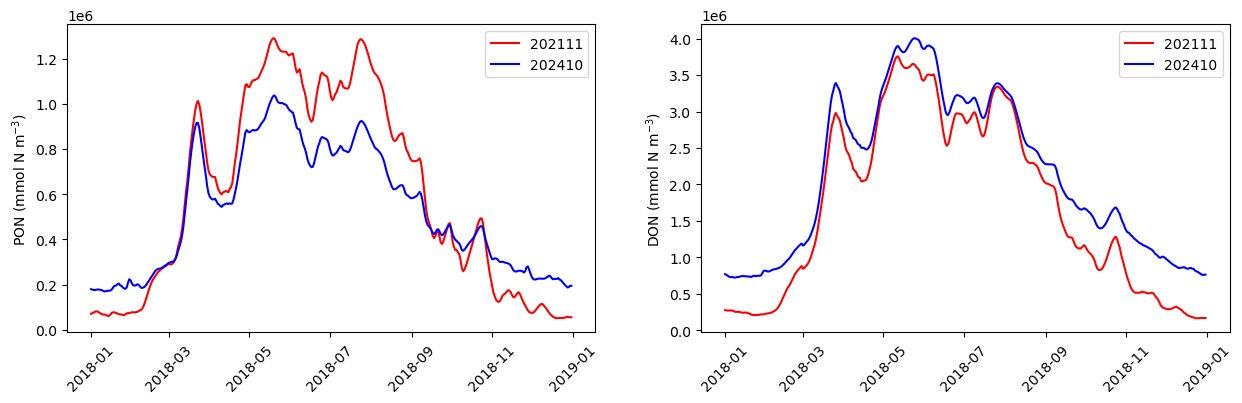

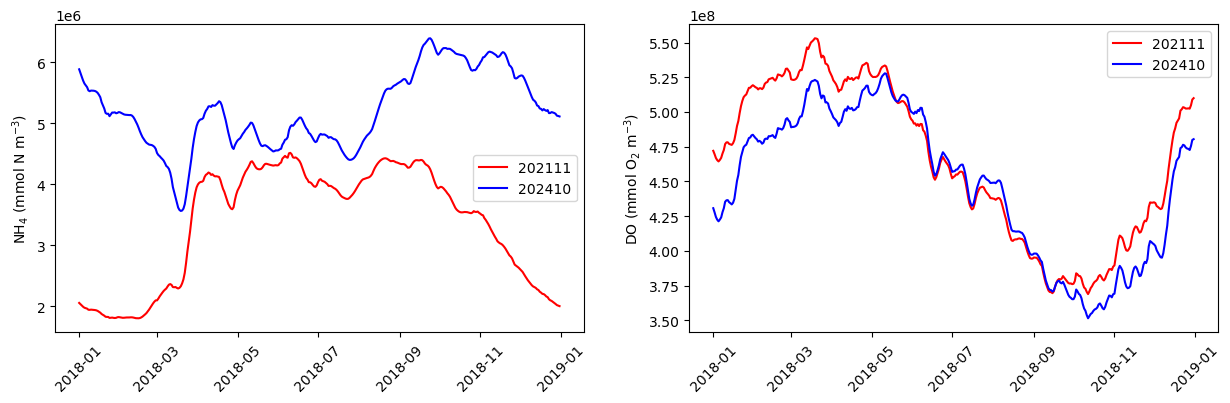

In [6]:
grazing = '$G^{Z_2}$'
resp = '$E + M$'
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(time_index,Z2_21,'r',label='202111')
ax[0].plot(time_index,Z2,'b',label='202410')
ax[0].legend()
ax[0].tick_params(axis='x', labelrotation=45)
ax[0].set_ylabel('Z$_2$ biomass (mmol N m$^{-3}$)')
ax[1].plot(time_index,grz_list21,linestyle='solid',color='red',label=f'{grazing}')
ax[1].plot(time_index,grz_list,linestyle='solid',color='blue',label=f'{grazing}')
ax[1].plot(time_index,np.array(grz_list)*0.4,linestyle='dashed',color='blue',label='Sloppy eating')
ax[1].plot(time_index,res_list,linestyle='dotted',color='blue',label=f'{resp}')
ax[1].legend()
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].set_ylabel('Z$_2$ graz-resp rates (mmol N m$^{-3}$s$^{-1}$)')

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(time_index,pon_21,'r',label='202111')
ax[0].plot(time_index,pon,'b',label='202410')
ax[0].legend()
ax[0].tick_params(axis='x', labelrotation=45)
ax[0].set_ylabel('PON (mmol N m$^{-3}$)')
ax[1].plot(time_index,don_21,'r',label='202111')
ax[1].plot(time_index,don,'b',label='202410')
ax[1].legend()
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].set_ylabel('DON (mmol N m$^{-3}$)')


fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(time_index,nh4_21,'r',label='202111')
ax[0].plot(time_index,nh4,'b',label='202410')
ax[0].legend()
ax[0].tick_params(axis='x', labelrotation=45)
ax[0].set_ylabel('NH$_4$ (mmol N m$^{-3}$)')
ax[1].plot(time_index,do_21,'r',label='202111')
ax[1].plot(time_index,do,'b',label='202410')
ax[1].legend()
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].set_ylabel('DO (mmol O$_2$ m$^{-3}$)')





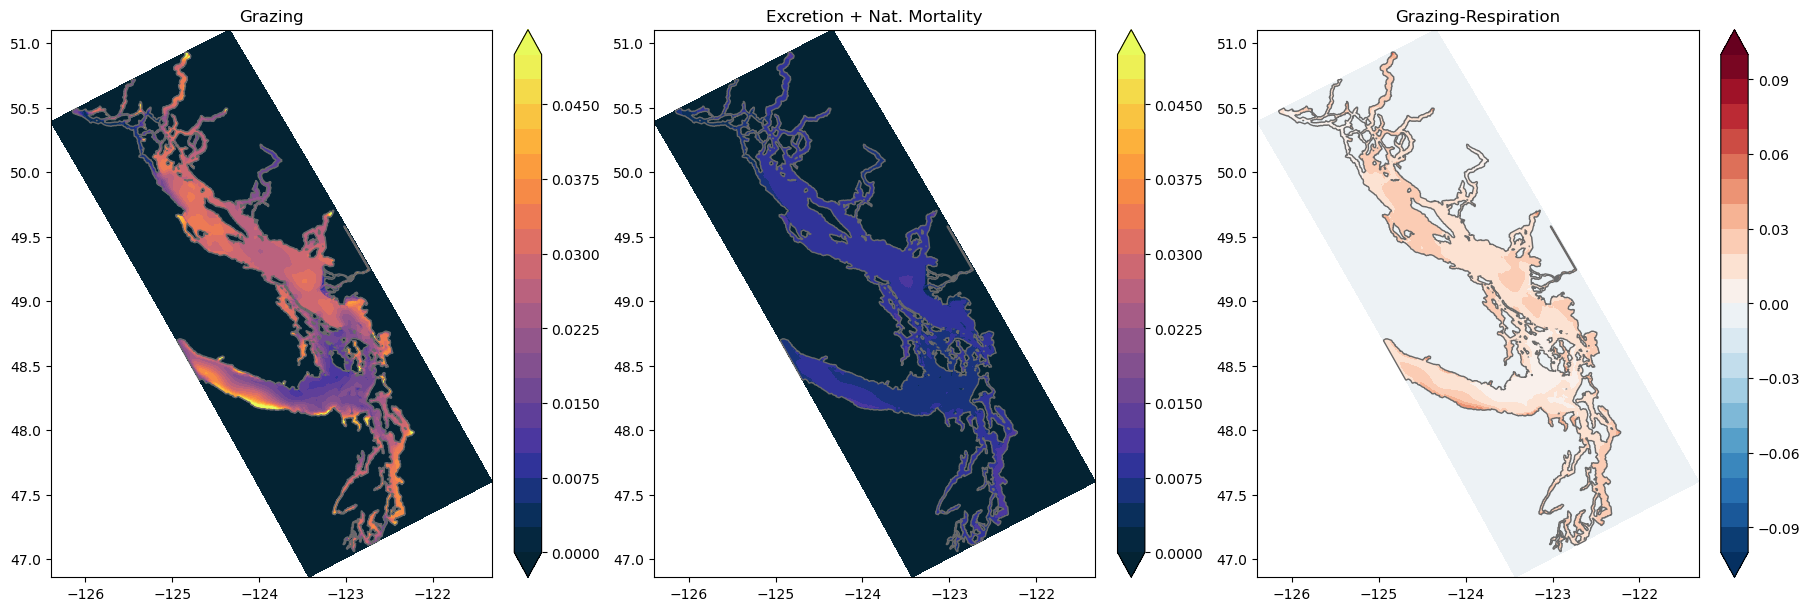

In [5]:

# Choose levels
levels = np.linspace(0, 0.05, 21)
cmap = cm.thermal

lon = mesh.nav_lon
lat = mesh.nav_lat

# Prepare figure
fig, axs = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

# Initial plots
axs[0].contour(lon, lat, mbathy[0,:,:], linewidths=1, levels=[-0.01, 0.01], colors='dimgray')
axs[1].contour(lon, lat, mbathy[0,:,:], linewidths=1, levels=[-0.01, 0.01], colors='dimgray')
axs[2].contour(lon, lat, mbathy[0,:,:], linewidths=1, levels=[-0.01, 0.01], colors='dimgray')
cf1 = axs[0].contourf(lon, lat, grz_da.sum(axis=0), levels=levels, cmap=cmap, extend='both')
cf2 = axs[1].contourf(lon, lat, mrt_da.sum(axis=0)+exc_da.sum(axis=0), levels=levels, cmap=cmap, extend='both')
cf3 = axs[2].contourf(lon, lat, grz_da.sum(axis=0)-mrt_da.sum(axis=0)-exc_da.sum(axis=0), levels=np.linspace(-0.1, 0.1, 21),cmap='RdBu_r', extend='both')

axs[0].set_title(f'Grazing')
axs[1].set_title(f'Excretion + Nat. Mortality')
axs[2].set_title(f'Grazing-Respiration')

# Colorbars
fig.colorbar(cf1, ax=axs[0])
fig.colorbar(cf2, ax=axs[1])
fig.colorbar(cf3, ax=axs[2])